# Existing `latent_soh` Features for SOH Prediction

This notebook uses the existing `ml_workspace/latent_soh` implementation as the latent-state generator and then compares prediction models in the same style as the manual Kalman notebook.

Workflow:

1. Build or load the existing `latent_soh` outputs
2. Use `latent_soh_filter_pct` and related latent diagnostics as causal predictive features
3. Use `next latent_soh_smooth_pct` as the denoised next-step target
4. Compare:
   - naive: next latent delta = 0
   - raw-only ridge
   - latent-enriched ridge
   - latent-enriched gradient boosting

This isolates the question you asked: does the repo's existing `latent_soh` implementation improve prediction when used as a feature/label layer?


## Setup

In [19]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


def resolve_timeseries_path(repo_root: Path) -> Path:
    preferred = repo_root / "data" / "event_timeseries_corrected.parquet"
    fallback = repo_root / "data" / "event_timeseries.parquet"
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not find local event_timeseries parquet")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.latent_soh.build_latent_soh import build_latent_soh_labels

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

PLANE_ID = "166"
RUN_LATENT_PIPELINE = False
RT_PROFILE = "balanced"
Q_DAY_SIGMA_PCT = 0.05
COMPARE_BACKEND = True

TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

TIMESERIES_PATH = resolve_timeseries_path(REPO_ROOT)
SPEC_PATH = REPO_ROOT / "ml_workspace" / "battery_specs.yaml"
LATENT_OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "latent_soh" / "output" / f"plane_{PLANE_ID}"
RESULT_DIR = REPO_ROOT / "ml_workspace" / "soh_estimation" / "output" / f"latent_impl_plane_{PLANE_ID}"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Timeseries:", TIMESERIES_PATH)
print("Latent output dir:", LATENT_OUTPUT_DIR)
print("Result dir:", RESULT_DIR)


Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Timeseries: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries_corrected.parquet
Latent output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/latent_soh/output/plane_166
Result dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_estimation/output/latent_impl_plane_166


## 1. Build or load the existing `latent_soh` outputs

In [20]:
if RUN_LATENT_PIPELINE:
    result = build_latent_soh_labels(
        plane_id=PLANE_ID,
        timeseries_path=TIMESERIES_PATH,
        spec_path=SPEC_PATH,
        output_dir=LATENT_OUTPUT_DIR,
        q_day_sigma_pct=Q_DAY_SIGMA_PCT,
        compare_backend=COMPARE_BACKEND,
        rt_profile=RT_PROFILE,
    )
    print(json.dumps(result, indent=2))
else:
    print("Using existing latent_soh outputs.")


Using existing latent_soh outputs.


In [21]:
event_df = pd.read_csv(LATENT_OUTPUT_DIR / "event_observation_table.csv", parse_dates=["event_datetime"])
latent_df = pd.read_csv(LATENT_OUTPUT_DIR / "latent_soh_event_table.csv", parse_dates=["event_datetime"])
summary = json.loads((LATENT_OUTPUT_DIR / "diagnostics" / "smoother_summary.json").read_text())

print("Event rows:", len(event_df))
print("Latent rows:", len(latent_df))
print("Smoother summary:")
display(pd.DataFrame([summary]))
display(
    latent_df.groupby("battery_id", as_index=False).agg(
        n_events=("flight_id", "count"),
        observed_soh_min=("observed_soh_pct", "min"),
        observed_soh_max=("observed_soh_pct", "max"),
        latent_filter_min=("latent_soh_filter_pct", "min"),
        latent_filter_max=("latent_soh_filter_pct", "max"),
        latent_smooth_min=("latent_soh_smooth_pct", "min"),
        latent_smooth_max=("latent_soh_smooth_pct", "max"),
    ).round(3)
)
display(latent_df.head(10))


Event rows: 1106
Latent rows: 1106
Smoother summary:


,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,166,balanced,"[1, 2]",1106,"{'1': 553, '2': 553}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 484.0, '2': 469.0}","{'1': 51.14722851352783, '2': 49.6942665930803}","{'1': 29.0, '2': 25.0}","{'1': 1.0244025838651254, '2': 1.0229620160775...","{'1': 0.2766726943942134, '2': 0.2567811934900...",FilterPy latent SOH is the canonical output. P...


,battery_id,n_events,observed_soh_min,observed_soh_max,latent_filter_min,latent_filter_max,latent_smooth_min,latent_smooth_max
0,1,553,40.0,100.0,52.819,99.976,52.819,96.545
1,2,553,42.0,100.0,55.932,99.977,55.932,96.847


,plane_id,battery_id,flight_id,event_datetime,event_type,observed_soh_pct,observed_soh_iqr_pct,observed_soh_span_pct,flag_new_est_batt_cap_any,flag_rst_coulomb_any,n_rows,event_duration_s,avg_cell_temp_mean_c,avg_cell_temp_min_c,avg_cell_temp_max_c,avg_cell_temp_span_c,current_abs_mean_a,p95_abs_current_a,current_span_a,voltage_mean_v,voltage_max_v,soc_mean_pct,soc_min_pct,soc_max_pct,soc_span_pct,kalman_coulomb_gap_mean_pct,kalman_coulomb_gap_span_pct,cap_est_delta_raw,cap_est_span_raw,p95_abs_dtemp_c_per_min,p95_abs_dcurrent_a_per_s,score_current,score_didt,score_dtemp,score_soc_edge,score_observation_instability,score_gap,score_switch,score_event_type,score_missing,sigma_base_pct,rt_profile,condition_multiplier,measurement_sigma_pct_raw,measurement_sigma_pct,measurement_var_pct2,delta_days,process_var_pct2,latent_soh_filterpy_filter_pct,latent_soh_filterpy_smooth_pct,latent_soh_filterpy_smooth_var_pct2,latent_soh_filterpy_smooth_std_pct,latent_soh_filter_pct,latent_soh_smooth_pct,latent_soh_smooth_var_pct2,latent_soh_smooth_std_pct,_filterpy_pred_var_pct2,_filterpy_pred_state_pct,latent_soh_pykalman_smooth_pct,latent_soh_pykalman_smooth_var_pct2,latent_soh_backend_delta_pct,latent_soh_backend_abs_delta_pct,latent_soh_monotone_pct,residual_pct,standardized_residual,resid_abs_mean_last_5_events,resid_std_last_5_events,resid_max_pos_last_5_events,resid_max_neg_last_5_events,resid_outlier_count_last_5_events,resid_abs_mean_last_30d,resid_std_last_30d,resid_outlier_count_last_30d,condition_multiplier_last_5_events_mean,score_switch_last_5_events_sum,score_observation_instability_last_5_events_mean
0,166,1,4575,2023-05-16 11:00:00,charge,100.0,0.0,0.0,0,1,15745,3148.773794,19.366211,18.0,21.0,3.0,7.928485,23.9,24.7,399.971204,404.0,92.914004,77.0,100.0,23.0,-0.160428,2.55,0.0,0.0,0.0,0.500425,0.597500,0.133272,0.0,1.0,0.0,1.307086,0.5,0.75,0.0,0.55,balanced,2.344184,1.289301,1.289301,1.662298,0.000100,2.500000e-07,99.950946,96.545359,0.048136,0.219400,99.950946,96.545359,0.048136,0.219400,100.000000,97.000000,96.545359,0.048136,-5.542233e-13,5.542233e-13,96.545359,3.454641,2.679467,3.454641,0.000000,3.454641,3.454641,1.0,3.454641,0.000000,1.0,2.344184,0.5,0.00
1,166,1,4576,2023-05-16 12:44:00,other,100.0,0.0,0.0,0,1,9638,1927.385601,21.981531,0.0,25.0,25.0,39.186315,54.1,70.2,362.911289,401.9,68.764889,29.0,100.0,71.0,-0.875459,1.76,9611.0,9611.0,0.0,6.453240,0.450833,0.659758,0.0,1.0,0.0,1.055092,0.5,0.25,0.0,0.55,balanced,2.305847,1.268216,1.268216,1.608372,0.072222,1.805556e-04,99.975677,96.544983,0.047966,0.219012,99.975677,96.544983,0.047966,0.219012,1.635298,99.950946,96.544983,0.047966,-5.542233e-13,5.542233e-13,96.544983,3.455017,2.724312,3.454829,0.000188,3.455017,3.454641,2.0,3.454829,0.000266,2.0,2.325016,1.0,0.00
2,166,1,4577,2023-05-16 13:00:00,charge,97.0,3.0,3.0,1,1,18774,3754.583319,24.594759,0.0,25.0,25.0,19.859817,27.8,28.7,384.956695,403.9,70.749867,29.0,100.0,71.0,-1.070712,0.85,9519.0,9611.0,0.0,0.500641,0.695000,0.133319,0.0,1.0,3.0,0.639142,1.5,0.75,0.0,0.55,balanced,5.192570,2.855914,2.855914,8.156243,0.011111,2.777778e-05,99.706589,96.544866,0.047942,0.218956,99.706589,96.544866,0.047942,0.218956,0.810889,99.975677,96.544866,0.047942,-5.542233e-13,5.542233e-13,96.544866,0.455134,0.159366,2.454931,1.414070,3.455017,0.455134,2.0,2.454931,1.731874,2.0,3.280867,2.5,1.00
3,166,1,4578,2023-05-16 14:35:00,other,97.0,0.0,0.0,0,1,11409,2281.582631,23.502586,23.0,25.0,2.0,31.840792,37.3,70.4,365.043676,400.5,66.621439,29.0,100.0,71.0,-0.238266,1.09,0.0,0.0,0.0,5.486243,0.310833,0.614114,0.0,1.0,0.0,0.592653,0.5,0.25,0.0,0.55,balanced,2.078858,1.143372,1.143372,1.307300,0.065972,1.649306e-04,98.730209,96.544159,0.047798,0.218628,98.730209,96.544159,0.047798,0.218628,0.737726,99.706589,96.544159,0.047798,-5.542233e-13,5.542233e-13,96.544159,0.455841,0.398682,1.955158,1.499670,3.455017,0.455134,2.0,1.955158,1.731670,2.0,2.980365,3.0,0.75
4,166,1,4579,2023-05-16 15:00:00,charge,96.0,1.0,1.0,1,1,20922,4184.178628,25.281

## 2. Visual check: observed SOH vs latent SOH

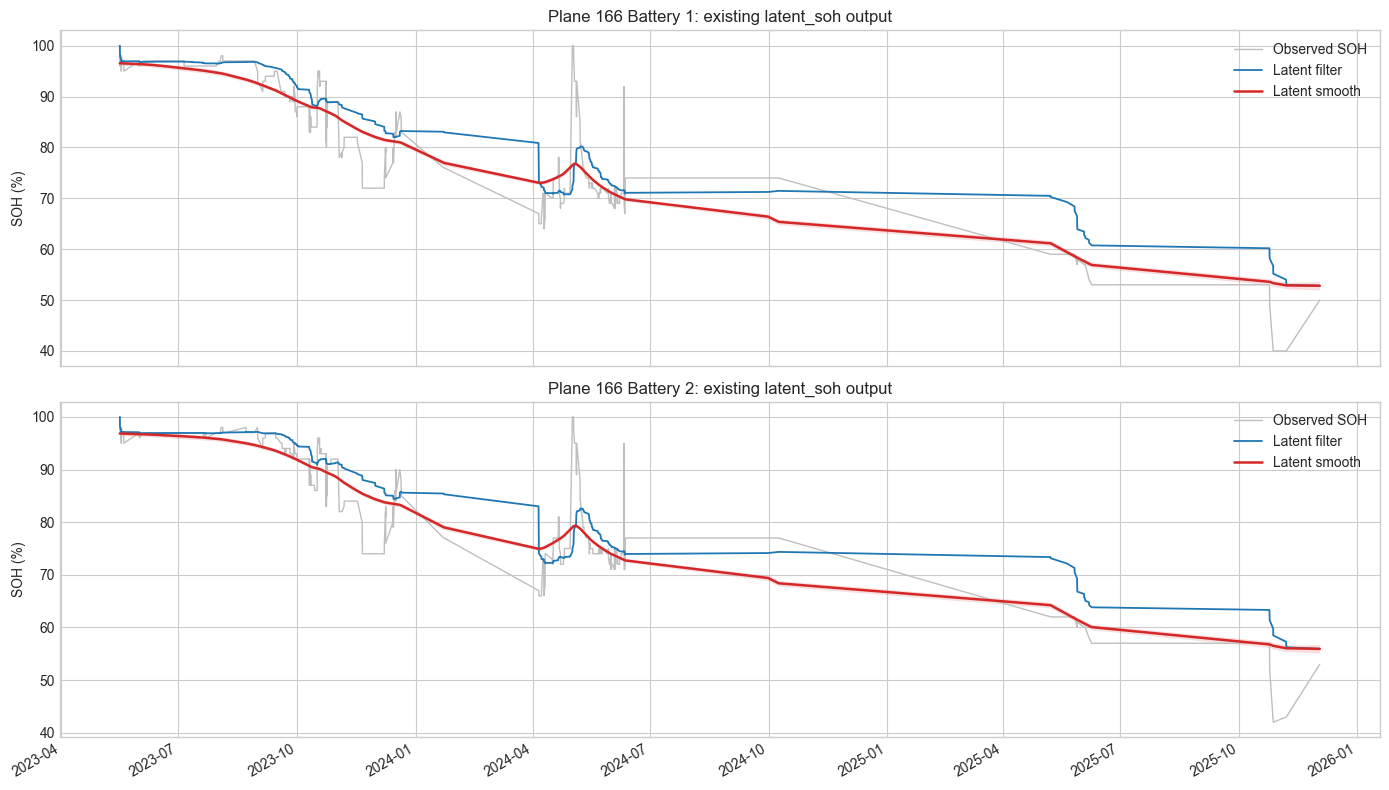

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (battery_id, group) in zip(axes, latent_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    ax.plot(g["event_datetime"], g["observed_soh_pct"], color="0.75", linewidth=1.0, label="Observed SOH")
    ax.plot(g["event_datetime"], g["latent_soh_filter_pct"], color="#1f77b4", linewidth=1.3, label="Latent filter")
    ax.plot(g["event_datetime"], g["latent_soh_smooth_pct"], color="#d62728", linewidth=1.8, label="Latent smooth")
    ax.fill_between(
        g["event_datetime"],
        g["latent_soh_smooth_pct"] - 2.0 * g["latent_soh_smooth_std_pct"],
        g["latent_soh_smooth_pct"] + 2.0 * g["latent_soh_smooth_std_pct"],
        color="#d62728",
        alpha=0.15,
        linewidth=0,
    )
    ax.set_title(f"Plane {PLANE_ID} Battery {battery_id}: existing latent_soh output")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()


## 3. Build the predictive dataset

Important choices:

- target: `next_latent_soh_smooth_pct`
- delta target: `next_delta_latent_pct`
- causal latent features come from filter-side quantities, not future-aware smoother values

That means we use the smoother as the denoised label, but the model inputs remain causal.


In [23]:
work = latent_df.sort_values(["battery_id", "event_datetime", "flight_id"]).copy()
work["next_latent_soh_smooth_pct"] = work.groupby(["plane_id", "battery_id"], sort=False)["latent_soh_smooth_pct"].shift(-1)
work["next_observed_soh_pct"] = work.groupby(["plane_id", "battery_id"], sort=False)["observed_soh_pct"].shift(-1)
work["next_delta_latent_pct"] = work["next_latent_soh_smooth_pct"] - work["latent_soh_filter_pct"]
work["next_delta_observed_pct"] = work["next_observed_soh_pct"] - work["observed_soh_pct"]
work["next_gap_days"] = work.groupby(["plane_id", "battery_id"], sort=False)["delta_days"].shift(-1)
work["battery_id_str"] = work["battery_id"].astype(str)

predictive_df = work[work["next_latent_soh_smooth_pct"].notna()].copy()

raw_feature_cols = [
    "observed_soh_pct",
    "current_abs_mean_a",
    "p95_abs_current_a",
    "avg_cell_temp_mean_c",
    "avg_cell_temp_span_c",
    "soc_mean_pct",
    "soc_span_pct",
    "event_duration_s",
    "measurement_sigma_pct",
    "condition_multiplier",
]

latent_feature_cols = [
    "latent_soh_filter_pct",
    "latent_soh_filterpy_filter_pct",
    "_filterpy_pred_state_pct",
    "_filterpy_pred_var_pct2",
    "measurement_sigma_pct",
    "condition_multiplier",
]

available_raw = [c for c in raw_feature_cols if c in predictive_df.columns]
available_latent = [c for c in latent_feature_cols if c in predictive_df.columns]

display(
    predictive_df[
        [
            "battery_id",
            "event_datetime",
            "observed_soh_pct",
            "latent_soh_filter_pct",
            "latent_soh_smooth_pct",
            "_filterpy_pred_state_pct",
            "_filterpy_pred_var_pct2",
            "next_latent_soh_smooth_pct",
            "next_delta_latent_pct",
        ]
    ].head(12).round(4)
)


,battery_id,event_datetime,observed_soh_pct,latent_soh_filter_pct,latent_soh_smooth_pct,_filterpy_pred_state_pct,_filterpy_pred_var_pct2,next_latent_soh_smooth_pct,next_delta_latent_pct
0,1,2023-05-16 11:00:00,100.0,99.9509,96.5454,97.0000,100.0000,96.5450,-3.4060
1,1,2023-05-16 12:44:00,100.0,99.9757,96.5450,99.9509,1.6353,96.5449,-3.4308
2,1,2023-05-16 13:00:00,97.0,99.7066,96.5449,99.9757,0.8109,96.5442,-3.1624
3,1,2023-05-16 14:35:00,97.0,98.7302,96.5442,99.7066,0.7377,96.5440,-2.1863
4,1,2023-05-16 15:00:00,96.0,98.4170,96.5440,98.7302,0.4716,96.5420,-1.8750
5,1,2023-05-16 19:11:00,96.0,97.8292,96.5420,98.4170,0.4180,96.5417,-1.2875
6,1,2023-05-16 20:00:00,97.0,97.7662,96.5417,97.8292,0.3164,96.5411,-1.2251
7,1,2023-05-16 21:19:00,97.0,97.6174,96.5411,97.7662,0.2925,96.5408,-1.0766
8,1,2023-05-16 22:00:00,97.0,97.5515,96.5408,97.6174,0.2358,96.5340,-1.0175
9,1,2023-05-17 11:30:00,96.0,97.4231,96.5340,97.5515,0.2120,96.5331,-0.8899


## 4. Split and utilities

In [24]:
def time_split(df: pd.DataFrame, train_frac: float, valid_frac: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = df.sort_values("event_datetime").reset_index(drop=True)
    n = len(work)
    n_train = max(1, int(round(n * train_frac)))
    n_valid = max(1, int(round(n * valid_frac))) if n >= 3 else max(0, n - n_train)
    if n_train + n_valid >= n:
        n_valid = max(1, n - n_train - 1) if n >= 3 else max(0, n - n_train)
    train = work.iloc[:n_train].copy()
    valid = work.iloc[n_train : n_train + n_valid].copy()
    test = work.iloc[n_train + n_valid :].copy()
    return train, valid, test


def make_feature_frame(df: pd.DataFrame, include_latent: bool) -> pd.DataFrame:
    cols = list(dict.fromkeys(available_raw + (available_latent if include_latent else [])))
    numeric = df[cols].apply(pd.to_numeric, errors="coerce").copy()
    numeric = numeric.fillna(numeric.median()).fillna(0.0)
    battery_dummies = pd.get_dummies(df["battery_id_str"], prefix="battery")
    event_dummies = pd.get_dummies(df["event_type"].fillna("unknown"), prefix="event_type")
    return pd.concat([numeric.reset_index(drop=True), battery_dummies.reset_index(drop=True), event_dummies.reset_index(drop=True)], axis=1)


def align_columns(train_x: pd.DataFrame, other_x: pd.DataFrame) -> pd.DataFrame:
    return other_x.reindex(columns=train_x.columns, fill_value=0.0)


def metric_table(y_true_level: np.ndarray, y_pred_level: np.ndarray, y_true_delta: np.ndarray, y_pred_delta: np.ndarray) -> dict[str, float]:
    return {
        "level_mae": float(mean_absolute_error(y_true_level, y_pred_level)),
        "level_rmse": float(np.sqrt(mean_squared_error(y_true_level, y_pred_level))),
        "level_r2": float(r2_score(y_true_level, y_pred_level)),
        "delta_mae": float(mean_absolute_error(y_true_delta, y_pred_delta)),
        "delta_rmse": float(np.sqrt(mean_squared_error(y_true_delta, y_pred_delta))),
        "delta_r2": float(r2_score(y_true_delta, y_pred_delta)),
    }


train_df, valid_df, test_df = time_split(predictive_df, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC)
print("Train / valid / test:", len(train_df), len(valid_df), len(test_df))


Train / valid / test: 773 166 165


## Compare prediction models

We train three next-step predictors:

- naive: next latent delta = 0
- raw-only ridge: event features without latent state features
- latent-causal ridge: raw features plus strictly causal `latent_soh` filter-time features only


In [25]:
y_train = train_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_valid = valid_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_test = test_df["next_delta_latent_pct"].to_numpy(dtype=float)

current_level_train = train_df["latent_soh_filter_pct"].to_numpy(dtype=float)
current_level_valid = valid_df["latent_soh_filter_pct"].to_numpy(dtype=float)
current_level_test = test_df["latent_soh_filter_pct"].to_numpy(dtype=float)

X_train_raw = make_feature_frame(train_df, include_latent=False)
X_valid_raw = align_columns(X_train_raw, make_feature_frame(valid_df, include_latent=False))
X_test_raw = align_columns(X_train_raw, make_feature_frame(test_df, include_latent=False))

X_train_latent = make_feature_frame(train_df, include_latent=True)
X_valid_latent = align_columns(X_train_latent, make_feature_frame(valid_df, include_latent=True))
X_test_latent = align_columns(X_train_latent, make_feature_frame(test_df, include_latent=True))

scaler_raw = StandardScaler()
scaler_latent = StandardScaler()
X_train_raw_s = scaler_raw.fit_transform(X_train_raw)
X_valid_raw_s = scaler_raw.transform(X_valid_raw)
X_test_raw_s = scaler_raw.transform(X_test_raw)
X_train_latent_s = scaler_latent.fit_transform(X_train_latent)
X_valid_latent_s = scaler_latent.transform(X_valid_latent)
X_test_latent_s = scaler_latent.transform(X_test_latent)

candidate_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

def fit_best_ridge(X_train, y_train, X_valid, y_valid):
    best = None
    best_mae = float("inf")
    for alpha in candidate_alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        mae = mean_absolute_error(y_valid, pred)
        if mae < best_mae:
            best = model
            best_mae = mae
    return best


naive_pred_delta = np.zeros_like(y_test)
naive_pred_level = current_level_test + naive_pred_delta

raw_ridge = fit_best_ridge(X_train_raw_s, y_train, X_valid_raw_s, y_valid)
raw_pred_delta = raw_ridge.predict(X_test_raw_s)
raw_pred_level = current_level_test + raw_pred_delta

latent_ridge = fit_best_ridge(X_train_latent_s, y_train, X_valid_latent_s, y_valid)
latent_ridge_pred_delta = latent_ridge.predict(X_test_latent_s)
latent_ridge_pred_level = current_level_test + latent_ridge_pred_delta

test_target_level = test_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float)

metrics = pd.DataFrame(
    [
        {"model": "naive_zero_delta", **metric_table(test_target_level, naive_pred_level, y_test, naive_pred_delta)},
        {"model": "ridge_raw_only", **metric_table(test_target_level, raw_pred_level, y_test, raw_pred_delta)},
        {"model": "ridge_latent_causal", **metric_table(test_target_level, latent_ridge_pred_level, y_test, latent_ridge_pred_delta)},
    ]
)
display(metrics.round(4))


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
1,ridge_raw_only,3.1612,4.4254,0.6062,3.1612,4.4254,-1.5040
2,ridge_latent_causal,3.7169,4.6991,0.5560,3.7169,4.6991,-1.8233


## 5. Prediction plots

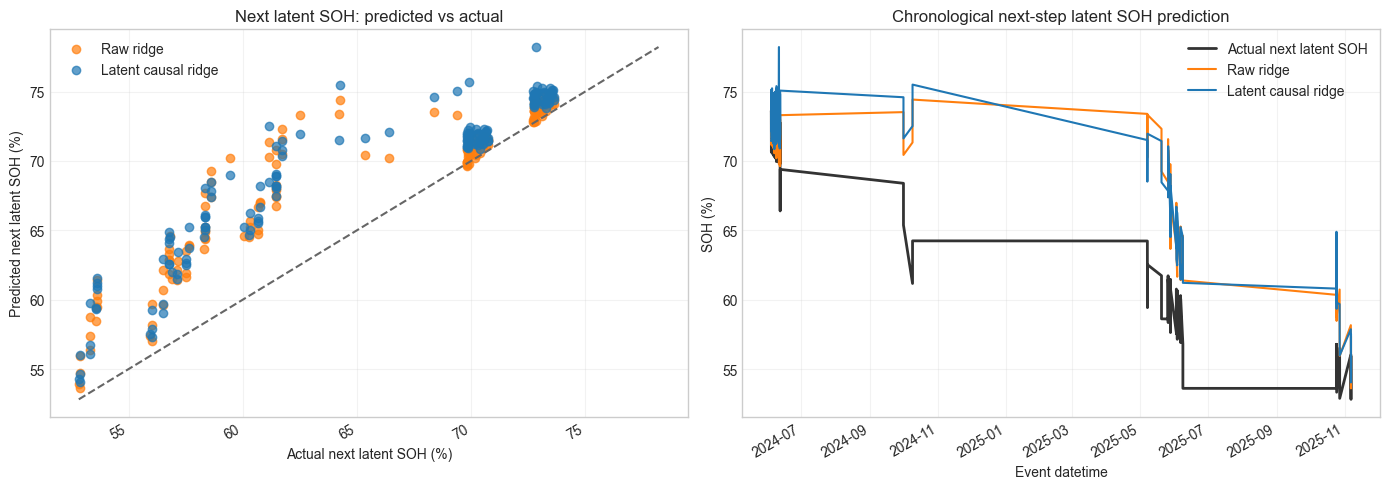

In [26]:
plot_df = test_df[["battery_id", "event_datetime", "latent_soh_filter_pct", "next_latent_soh_smooth_pct", "next_observed_soh_pct"]].copy()
plot_df["pred_next_level_raw_ridge"] = raw_pred_level
plot_df["pred_next_level_latent_ridge"] = latent_ridge_pred_level
plot_df["pred_next_delta_raw_ridge"] = raw_pred_delta
plot_df["pred_next_delta_latent_ridge"] = latent_ridge_pred_delta

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_df["next_latent_soh_smooth_pct"], plot_df["pred_next_level_raw_ridge"], alpha=0.7, label="Raw ridge", color="#ff7f0e")
axes[0].scatter(plot_df["next_latent_soh_smooth_pct"], plot_df["pred_next_level_latent_ridge"], alpha=0.7, label="Latent causal ridge", color="#1f77b4")
lo = min(plot_df["next_latent_soh_smooth_pct"].min(), plot_df["pred_next_level_latent_ridge"].min(), plot_df["pred_next_level_raw_ridge"].min())
hi = max(plot_df["next_latent_soh_smooth_pct"].max(), plot_df["pred_next_level_latent_ridge"].max(), plot_df["pred_next_level_raw_ridge"].max())
axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="0.4")
axes[0].set_title("Next latent SOH: predicted vs actual")
axes[0].set_xlabel("Actual next latent SOH (%)")
axes[0].set_ylabel("Predicted next latent SOH (%)")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

plot_df = plot_df.sort_values("event_datetime")
axes[1].plot(plot_df["event_datetime"], plot_df["next_latent_soh_smooth_pct"], color="0.2", linewidth=2, label="Actual next latent SOH")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_raw_ridge"], color="#ff7f0e", linewidth=1.5, label="Raw ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_latent_ridge"], color="#1f77b4", linewidth=1.5, label="Latent causal ridge")
axes[1].set_title("Chronological next-step latent SOH prediction")
axes[1].set_xlabel("Event datetime")
axes[1].set_ylabel("SOH (%)")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()


## 6. Which existing latent features matter?

In [27]:
coef_df = pd.DataFrame(
    {
        "feature": X_train_latent.columns,
        "coef": latent_ridge.coef_,
        "abs_coef": np.abs(latent_ridge.coef_),
    }
).sort_values("abs_coef", ascending=False)
display(coef_df.head(20).round(4))


,feature,coef,abs_coef
12,_filterpy_pred_state_pct,-3.0707,3.0707
0,observed_soh_pct,1.3631,1.3631
3,avg_cell_temp_mean_c,-0.3997,0.3997
11,latent_soh_filterpy_filter_pct,0.2969,0.2969
10,latent_soh_filter_pct,0.2969,0.2969
1,current_abs_mean_a,0.2950,0.2950
7,event_duration_s,-0.2690,0.2690
2,p95_abs_current_a,-0.2303,0.2303
6,soc_span_pct,0.2113,0.2113
14,battery_1,-0.1209,0.1209


## 7. Save outputs

In [28]:
predictive_df.to_csv(RESULT_DIR / "latent_impl_predictive_dataset.csv", index=False)
plot_df.to_csv(RESULT_DIR / "latent_impl_test_predictions.csv", index=False)
metrics.to_csv(RESULT_DIR / "latent_impl_prediction_metrics.csv", index=False)
coef_df.to_csv(RESULT_DIR / "latent_impl_ridge_coefficients.csv", index=False)

print("Saved outputs to", RESULT_DIR)


Saved outputs to /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_estimation/output/latent_impl_plane_166


## 8. Interpretation

In [29]:
display(metrics.round(4))
best_row = metrics.sort_values("level_mae").iloc[0]
print(f"Best model by next-level MAE: {best_row['model']}")
print("- This comparison is now restricted to strictly causal latent features available at filter time.")
print("- If `ridge_latent_causal` beats `ridge_raw_only`, then the existing latent filter state is adding genuine forecasting signal beyond raw event features.")
print("- The most informative causal latent features are typically current filter level, one-step-ahead predicted state, predicted variance, and condition-aware measurement uncertainty.")


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
1,ridge_raw_only,3.1612,4.4254,0.6062,3.1612,4.4254,-1.5040
2,ridge_latent_causal,3.7169,4.6991,0.5560,3.7169,4.6991,-1.8233


Best model by next-level MAE: ridge_raw_only
- This comparison is now restricted to strictly causal latent features available at filter time.
- If `ridge_latent_causal` beats `ridge_raw_only`, then the existing latent filter state is adding genuine forecasting signal beyond raw event features.
- The most informative causal latent features are typically current filter level, one-step-ahead predicted state, predicted variance, and condition-aware measurement uncertainty.
